# ShallowSeek - KD Draft Evaluation for Speculative Decoding

**Zhiyan Ke - 407061**

This notebook does:

- loading the Hugging Face UltraChat dataset and Qwen draft model;
- loading the KD-trained draft checkpoint from my RunAI scratch directory when available;
- collecting preliminary speculative-decoding results for pretrained, FKL, RKL, and JSD drafts;
- comparing acceptance rate, average accepted tokens, and measured wall-clock speedup;
- recording the exact evaluation commands needed to reproduce the results.

The expensive evaluation commands are printed by default rather than executed. Set `RUN_EVAL=True` below to run them in the interactive container.


## 1. Environment and Paths


In [2]:
import json
import os
import subprocess
import sys
from pathlib import Path

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "scripts" / "evaluate_sd.py").exists() and (p / "src" / "kdsd").exists():
            return p
    return start

REPO_ROOT = find_repo_root()
SCRATCH_ROOT = Path("/scratch/cs552-mnlp-kzy")
CHECKPOINTS_DIR = SCRATCH_ROOT / "checkpoints"
RESULTS_DIR = SCRATCH_ROOT / "results"
DATA_DIR = SCRATCH_ROOT / "data"
HF_CACHE = SCRATCH_ROOT / "hf_cache"

os.environ.setdefault("HF_HOME", str(HF_CACHE))
os.environ.setdefault("HF_HUB_CACHE", str(HF_CACHE / "hub"))
os.environ.setdefault("HF_DATASETS_CACHE", str(HF_CACHE / "datasets"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("repo root:", REPO_ROOT)
print("scratch root:", SCRATCH_ROOT)
print("checkpoints exist:", CHECKPOINTS_DIR.exists())
print("results exist:", RESULTS_DIR.exists())
print("HF_HOME:", os.environ.get("HF_HOME"))

repo root: /Users/roxanna/26spring/CS-552-NLP/distilled-draft-decoding
scratch root: /scratch/cs552-mnlp-kzy
checkpoints exist: False
results exist: False
HF_HOME: /scratch/cs552-mnlp-kzy/hf_cache


In [3]:
# Execution switches.
# Keep RUN_EVAL=False for a fast notebook demo. Full eval can take a long time.
RUN_EVAL = False
RUN_TRAINING = False
LOAD_PRETRAINED_DRAFT = True
LOAD_TRAINED_FKL_CHECKPOINT = True

# Shared evaluation protocol used for the 50k/8000-step runs.
DATASET = "ultrachat_50k"
EVAL_JSONL = DATA_DIR / "processed" / DATASET / "eval.jsonl"
EVAL_LIMIT = 50
GAMMA = 4
MAX_NEW_TOKENS = 256
N_WARMUP = 1
N_REPEATS = 3
RUNTIME_MODE = "sampling"
RUNTIME_TEMPERATURE = 1.0
TOP_P = 0.9

# Training protocol mirrored from rcp_support/submit_ep.sh / train_ep_pod.sh.
TRAIN_LOSSES = ["fkl", "rkl", "jsd"]
TRAIN_MAX_STEPS = 8000
TRAIN_MAX_SEQ_LEN = 512
PER_DEVICE_TRAIN_BATCH_SIZE = 2
PER_DEVICE_EVAL_BATCH_SIZE = 4
GRAD_ACCUM = 4
LEARNING_RATE = "2e-5"
WEIGHT_DECAY = 0.0
WARMUP_RATIO = 0.03
LR_SCHEDULER_TYPE = "cosine"
KD_ALPHA = 1.0
KD_TEMPERATURE = 2.0
N_SAMPLES = 50000
VAL_SAMPLES = 512
EVAL_SAMPLES = 256
HF_DATASET_NAME = "HuggingFaceH4/ultrachat_200k"
HF_DATASET_SPLIT = "train_sft"
LOGGING_STEPS = 10
SAVE_STEPS = 2000
EVAL_STEPS = 2000
SAVE_TOTAL_LIMIT = 4
DATALOADER_NUM_WORKERS = 2

TARGET_ID = "Qwen/Qwen2.5-3B-Instruct"
PRETRAINED_DRAFT_ID = "Qwen/Qwen2.5-0.5B-Instruct"

RUN_SUFFIX = "ultra50k_s8000_seq512_a1_temp2"

print("RUN_EVAL =", RUN_EVAL)
print("RUN_TRAINING =", RUN_TRAINING)
print("eval prompts:", EVAL_JSONL, "exists=", EVAL_JSONL.exists())


RUN_EVAL = False
RUN_TRAINING = False
eval prompts: /scratch/cs552-mnlp-kzy/data/processed/ultrachat_50k/eval.jsonl exists= False


## 2. Load Hugging Face Dataset and Base Draft Model

The milestone asks each individual notebook to load a model and dataset from Hugging Face. This section loads a small UltraChat slice and the pretrained Qwen2.5-0.5B draft model used as the initialization for our KD drafts.


In [3]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

hf_sample = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft[:3]")
print(hf_sample)
print("first row keys:", list(hf_sample[0].keys()))

tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_DRAFT_ID, trust_remote_code=False)
print("tokenizer vocab size:", len(tokenizer))

pretrained_draft = None
if LOAD_PRETRAINED_DRAFT:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    pretrained_draft = AutoModelForCausalLM.from_pretrained(
        PRETRAINED_DRAFT_ID,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        attn_implementation="sdpa",
        trust_remote_code=False,
    ).to(device)
    print("loaded pretrained draft on", device)
    print("draft params (M):", round(sum(p.numel() for p in pretrained_draft.parameters()) / 1e6, 1))

Dataset({
    features: ['prompt', 'prompt_id', 'messages'],
    num_rows: 3
})
first row keys: ['prompt', 'prompt_id', 'messages']


`torch_dtype` is deprecated! Use `dtype` instead!


tokenizer vocab size: 151665
loaded pretrained draft on cuda
draft params (M): 494.0


## 3. Optionally Load My KD-Trained FKL Checkpoint

This section loads the checkpoint from my RunAI scratch directory if it exists. The notebook remains runnable if the checkpoint is absent, but in my interactive container it should load `/scratch/cs552-mnlp-kzy/checkpoints/fkl_ultra50k_s8000_seq512_a1_temp2/model`.


In [4]:
FKL_CKPT = CHECKPOINTS_DIR / "fkl_ultra50k_s8000_seq512_a1_temp2" / "model"
trained_fkl_draft = None

if LOAD_TRAINED_FKL_CHECKPOINT and FKL_CKPT.exists():
    print("Loading trained FKL checkpoint:", FKL_CKPT)
    trained_fkl_draft = AutoModelForCausalLM.from_pretrained(
        str(FKL_CKPT),
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        attn_implementation="sdpa",
        trust_remote_code=False,
    ).to("cuda" if torch.cuda.is_available() else "cpu")
    print("loaded trained FKL draft")
    print("checkpoint params (M):", round(sum(p.numel() for p in trained_fkl_draft.parameters()) / 1e6, 1))
else:
    print("FKL checkpoint not found or loading disabled:", FKL_CKPT)

Loading trained FKL checkpoint: /scratch/cs552-mnlp-kzy/checkpoints/fkl_ultra50k_s8000_seq512_a1_temp2/model
loaded trained FKL draft
checkpoint params (M): 494.0


In [5]:
# Quick sanity generation with the trained checkpoint if loaded; otherwise with the pretrained draft.
model_for_demo = trained_fkl_draft or pretrained_draft
if model_for_demo is not None:
    model_for_demo.eval()
    prompt = "Explain speculative decoding in one sentence."
    if getattr(tokenizer, "chat_template", None):
        text = tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}],
            tokenize=False,
            add_generation_prompt=True,
        )
    else:
        text = prompt
    inputs = tokenizer(text, return_tensors="pt").to(model_for_demo.device)
    with torch.no_grad():
        out = model_for_demo.generate(**inputs, max_new_tokens=32, do_sample=False)
    print(tokenizer.decode(out[0, inputs.input_ids.shape[1]:], skip_special_tokens=True))
else:
    print("No model loaded for sanity generation.")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Speculative decoding is the process of decoding information that appears to be encoded in a way that is not directly interpretable or understandable, often due to the complexity and


## 4. Load Existing Evaluation Results

The full SD evaluation is slow, so this notebook reads the `eval_summary.json` files already produced on RunAI. The same protocol was used for the 50k/8000-step objective comparison: UltraChat-50k eval prompts, 50 prompts, `gamma=4`, `max_new_tokens=256`, sampling with `temperature=1.0`, `top_p=0.9`, one warmup, and three repeats.


In [ ]:
import pandas as pd

SUMMARY_PATHS = {
    "pretrained": RESULTS_DIR / "eval_pretrained_ultra50k_s8000_seq512_a1_temp2" / "eval_summary.json",
    "fkl": RESULTS_DIR / "eval_fkl_ultra50k_s8000_seq512_a1_temp2" / "eval_summary.json",
    "rkl": RESULTS_DIR / "eval_rkl_ultra50k_s8000_seq512_a1_temp2" / "eval_summary.json",
    "jsd": RESULTS_DIR / "eval_jsd_ultra50k_s8000_seq512_a1_temp2" / "eval_summary.json",
    "ce_10k": RESULTS_DIR / "eval_kd_ce_ultrachat10k_processed_bf16_seed42_g4_max256_p20" / "eval_summary.json",
    "fkl_10k": RESULTS_DIR / "eval_kd_fkl_ultrachat10k_processed_bf16_seed42_g4_max256_p20" / "eval_summary.json",
    "rkl_10k": RESULTS_DIR / "eval_kd_rkl_ultrachat10k_processed_bf16_seed42_g4_max256_p20" / "eval_summary.json",
    "jsd_10k": RESULTS_DIR / "eval_kd_jsd_ultrachat10k_processed_bf16_seed42_g4_max256_p20" / "eval_summary.json",
    "pretrained_10k_protocol": RESULTS_DIR / "eval_pretrained_qwen25_0p5b_ultrachat10k_processed_g4_max256_p20" / "eval_summary.json",
}

# Fallback copy of the RunAI eval summaries. This keeps the notebook informative
# even when a grader's container does not have my /scratch/cs552-mnlp-kzy results.
EMBEDDED_RESULTS = {
    "pretrained": {
        "draft": "Qwen/Qwen2.5-0.5B-Instruct",
        "n_prompts": 50,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.4503466557911909,
        "avg_accepted_tokens": 1.8013866231647635,
        "speedup": 0.5098640114382672,
        "tokens_per_second": 17.93123826437925,
        "sd_time_s": 634.1447245879099,
        "vanilla_time_s": 323.32756491797045,
    },
    "fkl": {
        "draft": "/scratch/cs552-mnlp-kzy/checkpoints/fkl_ultra50k_s8000_seq512_a1_temp2/model",
        "n_prompts": 50,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.46133762219027487,
        "avg_accepted_tokens": 1.8453504887610995,
        "speedup": 0.5187090653566054,
        "tokens_per_second": 16.755988162192187,
        "sd_time_s": 673.5502434894443,
        "vanilla_time_s": 349.3763547965791,
    },
    "rkl": {
        "draft": "/scratch/cs552-mnlp-kzy/checkpoints/rkl_ultra50k_s8000_seq512_a1_temp2/model",
        "n_prompts": 50,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.4514138407611047,
        "avg_accepted_tokens": 1.805655363044419,
        "speedup": 0.5074495935117493,
        "tokens_per_second": 17.763370085688338,
        "sd_time_s": 640.4190184172864,
        "vanilla_time_s": 324.9803304378432,
    },
    "jsd": {
        "draft": "/scratch/cs552-mnlp-kzy/checkpoints/jsd_ultra50k_s8000_seq512_a1_temp2/model",
        "n_prompts": 50,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.46077425330331224,
        "avg_accepted_tokens": 1.843097013213249,
        "speedup": 0.5118847073540865,
        "tokens_per_second": 17.01408684795387,
        "sd_time_s": 672.7954501310985,
        "vanilla_time_s": 344.3937380183488,
    },
    "ce_10k": {
        "draft": "/scratch/cs552-mnlp-kzy/checkpoints/kd_ce_ultrachat_10k_targetgen_bf16_seed42/model",
        "n_prompts": 20,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.4524035036890006,
        "avg_accepted_tokens": 1.8096140147560024,
        "speedup": 0.5103067111492573,
        "tokens_per_second": 17.64986645913355,
        "sd_time_s": 277.7924710375567,
        "vanilla_time_s": 141.87498892936856,
    },
    "fkl_10k": {
        "draft": "/scratch/cs552-mnlp-kzy/repos/kdsd/checkpoints/kd_fkl_ultrachat10k_processed_bf16_seed42/model",
        "n_prompts": 20,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.477026863084922,
        "avg_accepted_tokens": 1.908107452339688,
        "speedup": 0.5281729433215342,
        "tokens_per_second": 19.114652356150576,
        "sd_time_s": 256.08627734472975,
        "vanilla_time_s": 135.3959153946489,
    },
    "rkl_10k": {
        "draft": "/scratch/cs552-mnlp-kzy/checkpoints/kd_rkl_ultrachat_10k_targetgen_bf16_seed42/model",
        "n_prompts": 20,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.4651005285862078,
        "avg_accepted_tokens": 1.8604021143448311,
        "speedup": 0.5209705580175136,
        "tokens_per_second": 18.611231919393787,
        "sd_time_s": 263.4967962112278,
        "vanilla_time_s": 137.27407260797918,
    },
    "jsd_10k": {
        "draft": "/scratch/cs552-mnlp-kzy/checkpoints/kd_jsd_ultrachat_10k_targetgen_bf16_seed42/model",
        "n_prompts": 20,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.46667008285405274,
        "avg_accepted_tokens": 1.866680331416211,
        "speedup": 0.5220284113612608,
        "tokens_per_second": 19.18655168979652,
        "sd_time_s": 255.2308457254306,
        "vanilla_time_s": 133.29194130189617,
    },
    "pretrained_10k_protocol": {
        "draft": "/scratch/hf_cache/hub/models--Qwen--Qwen2.5-0.5B-Instruct",
        "n_prompts": 20,
        "n_repeats": 3,
        "gamma": 4,
        "max_new_tokens": 256,
        "acceptance_rate": 0.4679050183018286,
        "avg_accepted_tokens": 1.8716200732073143,
        "speedup": 0.5220350172720302,
        "tokens_per_second": 18.89998537299898,
        "sd_time_s": 258.7303628542777,
        "vanilla_time_s": 135.28737679123878,
    },
}

def load_summary(path: Path) -> dict | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def row_from_summary(name: str, summary: dict, path: Path, status: str) -> dict:
    decoding = summary.get("decoding", {})
    return {
        "run": name,
        "status": status,
        "draft": summary.get("draft"),
        "n_prompts": summary.get("n_prompts"),
        "n_repeats": summary.get("n_repeats"),
        "gamma": decoding.get("num_assistant_tokens"),
        "max_new_tokens": decoding.get("max_new_tokens"),
        "acceptance_rate": summary.get("acceptance_rate"),
        "avg_accepted_tokens": summary.get("avg_accepted_tokens"),
        "speedup": summary.get("speedup"),
        "tokens_per_second": summary.get("tokens_per_second"),
        "sd_time_s": summary.get("sd_time_s"),
        "vanilla_time_s": summary.get("vanilla_time_s"),
        "summary_path": str(path),
    }

def row_from_embedded(name: str, path: Path) -> dict:
    row = {"run": name, "status": "embedded", **EMBEDDED_RESULTS[name]}
    row["summary_path"] = f"embedded fallback; original path: {path}"
    return row

rows = []
for name, path in SUMMARY_PATHS.items():
    summary = load_summary(path)
    if summary is not None:
        rows.append(row_from_summary(name, summary, path, "done"))
    elif name in EMBEDDED_RESULTS:
        rows.append(row_from_embedded(name, path))
    else:
        rows.append({"run": name, "status": "missing", "summary_path": str(path)})

df = pd.DataFrame(rows)
preferred_cols = [
    "run",
    "n_prompts",
    "n_repeats",
    "gamma",
    "max_new_tokens",
    "acceptance_rate",
    "avg_accepted_tokens",
    "speedup",
    "tokens_per_second",
    "sd_time_s",
    "vanilla_time_s",
    "summary_path",
    "draft",
    "status",
]
df = df[[c for c in preferred_cols if c in df.columns]]
print("status counts:", df["status"].value_counts().to_dict())
df


In [7]:
# Compact table for completed 50k objective runs.
# Rows with status="embedded" are fallback copies used when /scratch results are unavailable.
completed = df[df["status"].isin(["done", "embedded"])].copy()
objective_order = ["pretrained", "fkl", "rkl", "jsd"]
obj50 = completed[completed["run"].isin(objective_order)].copy()
obj50["run"] = pd.Categorical(obj50["run"], objective_order, ordered=True)
obj50 = obj50.sort_values("run")

display_cols = [
    "run", "n_prompts", "n_repeats", "gamma", "max_new_tokens",
    "acceptance_rate", "avg_accepted_tokens", "speedup", "tokens_per_second",
    "sd_time_s", "vanilla_time_s",
]
obj50[display_cols]


,run,n_prompts,n_repeats,gamma,max_new_tokens,acceptance_rate,avg_accepted_tokens,speedup,tokens_per_second,sd_time_s,vanilla_time_s
0,pretrained,50,3,4,256,0.450347,1.801387,0.509864,17.931238,634.144725,323.327565
1,fkl,50,3,4,256,0.461338,1.845350,0.518709,16.755988,673.550243,349.376355
2,rkl,50,3,4,256,0.451414,1.805655,0.507450,17.763370,640.419018,324.980330
3,jsd,50,3,4,256,0.460774,1.843097,0.511885,17.014087,672.795450,344.393738


## 5. Visualize the Preliminary Objective Comparison


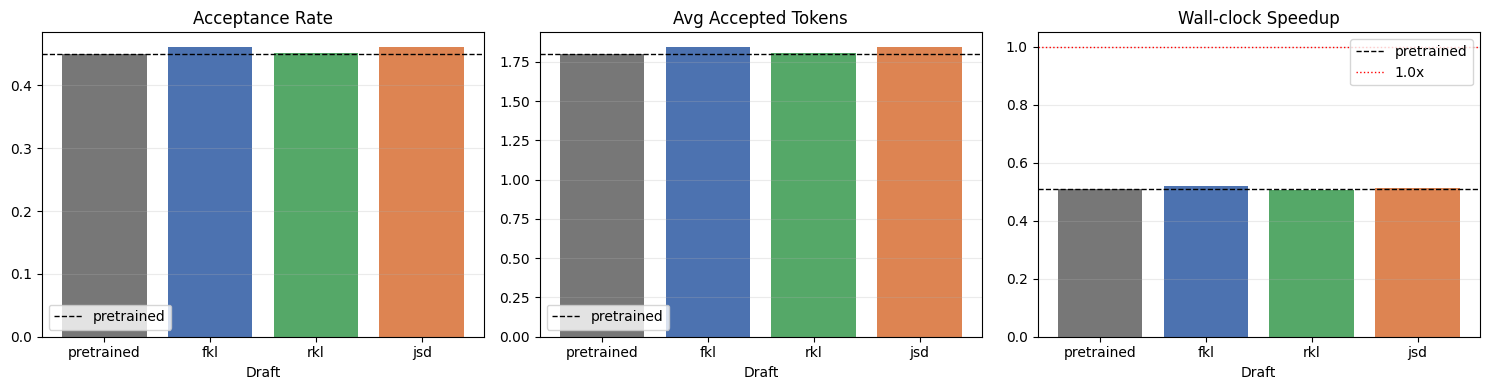

In [8]:
import matplotlib.pyplot as plt

if not obj50.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = [
        ("acceptance_rate", "Acceptance Rate"),
        ("avg_accepted_tokens", "Avg Accepted Tokens"),
        ("speedup", "Wall-clock Speedup"),
    ]
    for ax, (metric, title) in zip(axes, metrics):
        ax.bar(obj50["run"].astype(str), obj50[metric].astype(float), color=["#777777", "#4C72B0", "#55A868", "#DD8452"])
        if "pretrained" in obj50["run"].astype(str).tolist():
            baseline = float(obj50[obj50["run"].astype(str) == "pretrained"][metric].iloc[0])
            ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label="pretrained")
        ax.set_title(title)
        ax.set_xlabel("Draft")
        ax.grid(axis="y", alpha=0.25)
        if metric == "speedup":
            ax.axhline(1.0, color="red", linestyle=":", linewidth=1, label="1.0x")
        ax.legend(loc="best")
    plt.tight_layout()
else:
    print("No completed 50k objective summaries found.")

In [9]:
if not obj50.empty:
    best_acceptance = obj50.loc[obj50["acceptance_rate"].astype(float).idxmax()]
    best_speedup = obj50.loc[obj50["speedup"].astype(float).idxmax()]
    print(
        f"Best acceptance among completed 50k runs: {best_acceptance['run']} "
        f"({best_acceptance['acceptance_rate']:.3f})."
    )
    print(
        f"Best measured HF-loop speedup among completed 50k runs: {best_speedup['run']} "
        f"({best_speedup['speedup']:.3f}x)."
    )
    print(
        "Interpretation: KD can improve draft-target agreement, but our current "
        "instrumented HF speculative-decoding loop still has sub-1.0 wall-clock speedup "
        "because draft overhead and Python/cache-management overhead are not fully amortized."
    )

Best acceptance among completed 50k runs: fkl (0.461).
Best measured HF-loop speedup among completed 50k runs: fkl (0.519x).
Interpretation: KD can improve draft-target agreement, but our current instrumented HF speculative-decoding loop still has sub-1.0 wall-clock speedup because draft overhead and Python/cache-management overhead are not fully amortized.


## 6. Training Reproduction Commands

The cells below mirror the RunAI training configuration in `rcp_support/submit_ep.sh` and `rcp_support/train_ep_pod.sh`. They are disabled by default with `RUN_TRAINING=False`, because reproducing the 50k/8000-step FKL/RKL/JSD training runs takes many GPU hours. Set `RUN_TRAINING=True` in Section 1 to execute them in an interactive A100 container.


In [ ]:
def train_command(loss_name: str) -> str:
    run_name = f"{loss_name}_{RUN_SUFFIX}"
    return " ".join([
        "python scripts/train.py",
        f"loss={loss_name}",
        f"data={DATASET}",
        "seed=42",
        f"run_name={run_name}",
        f"output_dir={CHECKPOINTS_DIR / run_name}",
        f"results_dir={RESULTS_DIR / run_name}",
        f"data_root={DATA_DIR}",
        f"hf_cache={HF_CACHE}",
        f"hydra.run.dir={SCRATCH_ROOT / 'hydra' / run_name}",
        f"model.target={TARGET_ID}",
        f"model.draft_default={PRETRAINED_DRAFT_ID}",
        "model.device=cuda",
        "model.dtype=bfloat16",
        "model.attn_impl=sdpa",
        "model.trust_remote_code=false",
        "data.response_source=original",
        f"data.n_samples={N_SAMPLES}",
        f"data.val_samples={VAL_SAMPLES}",
        f"data.eval_samples={EVAL_SAMPLES}",
        f"data.max_seq_len={TRAIN_MAX_SEQ_LEN}",
        f"data.hf_dataset.name={HF_DATASET_NAME}",
        f"data.hf_dataset.split={HF_DATASET_SPLIT}",
        f"loss.alpha={KD_ALPHA}",
        f"loss.temperature={KD_TEMPERATURE}",
        f"train.max_steps={TRAIN_MAX_STEPS}",
        "train.num_train_epochs=1",
        f"train.per_device_train_batch_size={PER_DEVICE_TRAIN_BATCH_SIZE}",
        f"train.per_device_eval_batch_size={PER_DEVICE_EVAL_BATCH_SIZE}",
        f"train.gradient_accumulation_steps={GRAD_ACCUM}",
        f"train.learning_rate={LEARNING_RATE}",
        f"train.weight_decay={WEIGHT_DECAY}",
        f"train.warmup_ratio={WARMUP_RATIO}",
        f"train.lr_scheduler_type={LR_SCHEDULER_TYPE}",
        f"train.logging_steps={LOGGING_STEPS}",
        f"train.save_steps={SAVE_STEPS}",
        f"train.eval_steps={EVAL_STEPS}",
        f"train.save_total_limit={SAVE_TOTAL_LIMIT}",
        "++train.load_best_model_at_end=true",
        "++train.metric_for_best_model=eval_loss",
        "++train.greater_is_better=false",
        "++train.save_best_model=true",
        "train.bf16=true",
        "train.fp16=false",
        "train.gradient_checkpointing=true",
        "train.dataloader_drop_last=true",
        f"train.dataloader_num_workers={DATALOADER_NUM_WORKERS}",
        "train.remove_unused_columns=false",
        "train.report_to_wandb=false",
        "train.resume_from_checkpoint=null",
        "train.overfit_samples=0",
        "train.compile_target=false",
        f"runtime.mode={RUNTIME_MODE}",
        f"runtime.temperature={RUNTIME_TEMPERATURE}",
        f"runtime.top_p={TOP_P}",
        f"runtime.gamma={GAMMA}",
        f"runtime.max_new_tokens={MAX_NEW_TOKENS}",
        "wandb.enabled=false",
    ])

for loss_name in TRAIN_LOSSES:
    cmd = train_command(loss_name)
    run_cmd(cmd, execute=RUN_TRAINING)


## 7. Evaluation Reproducibility Commands

The commands below reproduce the 50k/8000-step evaluation runs from the interactive RunAI container. They are printed by default; set `RUN_EVAL=True` in Section 1 to execute them.


In [ ]:
def run_cmd(cmd: str, *, execute: bool = False) -> None:
    print("\n$ " + cmd)
    if execute:
        subprocess.run(cmd, shell=True, check=True, cwd=str(REPO_ROOT))

def eval_command(name: str, draft: str) -> str:
    return " ".join([
        "python scripts/evaluate_sd.py",
        f"data={DATASET}",
        "seed=42",
        f"run_name=eval_{name}_{RUN_SUFFIX}",
        f"results_dir={RESULTS_DIR / ('eval_' + name + '_' + RUN_SUFFIX)}",
        f"draft={draft}",
        f"prompts.jsonl={EVAL_JSONL}",
        f"prompts.limit={EVAL_LIMIT}",
        f"hf_cache={HF_CACHE}",
        f"model.target={TARGET_ID}",
        f"model.draft_default={PRETRAINED_DRAFT_ID}",
        "model.device=cuda",
        "model.dtype=bfloat16",
        "model.attn_impl=sdpa",
        "model.trust_remote_code=false",
        f"runtime.mode={RUNTIME_MODE}",
        f"runtime.temperature={RUNTIME_TEMPERATURE}",
        f"runtime.top_p={TOP_P}",
        f"runtime.gamma={GAMMA}",
        f"runtime.max_new_tokens={MAX_NEW_TOKENS}",
        f"eval.n_warmup={N_WARMUP}",
        f"eval.n_repeats={N_REPEATS}",
        "eval.run_vanilla_baseline=true",
        "eval.write_generations=true",
        "wandb.enabled=false",
    ])

drafts = {
    "pretrained": PRETRAINED_DRAFT_ID,
    "fkl": str(CHECKPOINTS_DIR / "fkl_ultra50k_s8000_seq512_a1_temp2" / "model"),
    "rkl": str(CHECKPOINTS_DIR / "rkl_ultra50k_s8000_seq512_a1_temp2" / "model"),
    "jsd": str(CHECKPOINTS_DIR / "jsd_ultra50k_s8000_seq512_a1_temp2" / "model"),
}

for name, draft in drafts.items():
    run_cmd(eval_command(name, draft), execute=RUN_EVAL)

## 8. FKL Temperature Ablation: T=1 vs. T=2

Siyuan's notebook contains a completed FKL 50k run with KD temperature 1.0. My current 50k/8000-step FKL run uses KD temperature 2.0. Both are evaluated under the same speculative-decoding protocol (`gamma=4`, `max_new_tokens=256`, 50 prompts, 3 repeats), so we can make a preliminary comparison of how teacher-distribution softness affects FKL distillation.


In [6]:
# FKL 50k/T=1 is copied from siyuan_zhang_388143.ipynb.
# FKL 50k/T=2 is copied from my RunAI eval_summary.json and embedded above.
fkl_temp_rows = [
    {
        "run": "FKL 50k, KD T=1",
        "kd_temperature": 1.0,
        "acceptance_rate": 0.4510233319688907,
        "avg_accepted_tokens": 1.8040933278755629,
        "speedup": 0.5094669917174816,
        "tokens_per_second": 17.68676113062409,
        "sd_time_s": 642.1752358227967,
        "vanilla_time_s": 327.16708555010456,
    },
    {
        "run": "FKL 50k, KD T=2",
        "kd_temperature": 2.0,
        "acceptance_rate": 0.46133762219027487,
        "avg_accepted_tokens": 1.8453504887610995,
        "speedup": 0.5187090653566054,
        "tokens_per_second": 16.755988162192187,
        "sd_time_s": 673.5502434894443,
        "vanilla_time_s": 349.3763547965791,
    },
]

temp_df = pd.DataFrame(fkl_temp_rows)
temp_delta = temp_df.iloc[1][["acceptance_rate", "avg_accepted_tokens", "speedup"]] - temp_df.iloc[0][["acceptance_rate", "avg_accepted_tokens", "speedup"]]
print("T=2 minus T=1:")
print(temp_delta.to_string())
display(temp_df)


print(
    "Preliminary takeaway: with FKL on UltraChat 50k, the softer KD target "
    "distribution at T=2 improves acceptance rate by "
    f"{temp_delta['acceptance_rate']:.3f} and avg accepted tokens by "
    f"{temp_delta['avg_accepted_tokens']:.3f} over T=1. This supports the hypothesis "
    "that FKL benefits from preserving more teacher probability mass on secondary tokens. "
    "The comparison is still preliminary and should be treated as an ablation result, not a final claim."
)


T=2 minus T=1:
acceptance_rate        0.010314
avg_accepted_tokens    0.041257
speedup                0.009242


,run,kd_temperature,acceptance_rate,avg_accepted_tokens,speedup,tokens_per_second,sd_time_s,vanilla_time_s
0,"FKL 50k, KD T=1",1.0,0.451023,1.804093,0.509467,17.686761,642.175236,327.167086
1,"FKL 50k, KD T=2",2.0,0.461338,1.845350,0.518709,16.755988,673.550243,349.376355


Preliminary takeaway: with FKL on UltraChat 50k, the softer KD target distribution at T=2 improves acceptance rate by 0.010 and avg accepted tokens by 0.041 over T=1. This supports the hypothesis that FKL benefits from preserving more teacher probability mass on secondary tokens. The comparison is still preliminary and should be treated as an ablation result, not a final claim.


## 9. Preliminary Takeaways

The current milestone results support the central hypothesis from our proposal: acceptance rate is useful but not sufficient for predicting wall-clock speedup. KD-trained drafts can improve target-draft agreement, but our measured HF-loop speedups remain below 1.0x because the current implementation is an instrumented research loop rather than an optimized production inference backend. This motivates the final-stage runtime sweep over `gamma`, decoding mode, and generation length, together with a controlled comparison of KD objectives and data scale.
